In [1]:
import pandas as pd

df = pd.read_csv('/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train.csv')


In [ ]:
import os
from pathlib import Path
from IPython.display import display, HTML
from tqdm.auto import tqdm

# ── Config ─────────────────────────────────────────────────────────────────
LOCAL_DATA_ROOT      = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9"
SOURCE_CSV_PATH      = "/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train.csv"
SAVE_SUGGESTIONS_CSV = True   # write `suggested_folders_<csv>.csv` next to source CSV
# ───────────────────────────────────────────────────────────────────────────
 
# ─────────────────────────────────────────────────────────────────────────
# REPORT 1 — STRICT CHECK: does the literal CSV image_path exist on disk?
# ─────────────────────────────────────────────────────────────────────────
exist_image: list[str] = []
missing_image: list[str] = []
exist_labels: list = []
missing_labels: list = []
_has_labels = "labels" in df.columns

for i, img_path in enumerate(tqdm(df["image_path"].astype(str),
                                  desc="Strict is_file()", unit="row")):
    lbl = df["labels"].iat[i] if _has_labels else None
    if os.path.isfile(img_path):
        exist_image.append(img_path)
        exist_labels.append(lbl)
    else:
        missing_image.append(img_path)
        missing_labels.append(lbl)

print(f"\nStrict check (CSV path exists on disk):")
print(f"  ✓ Found:   {len(exist_image):,}")
print(f"  ✗ Missing: {len(missing_image):,}")

# 3) Per-folder coverage summary (depth=1 → first folder above the file)
def _src_folder(path_str, depth: int = 1) -> str:
    p = Path(str(path_str))
    for _ in range(depth):
        p = p.parent
    return p.name

def _folder_segments(path_str, n: int = 4) -> str:
    parts = Path(str(path_str)).parent.parts
    return "/".join(parts[-n:]) if len(parts) >= n else "/".join(parts)

found_df   = pd.DataFrame({"image_path": exist_image})
missing_df = pd.DataFrame({"image_path": missing_image})
found_df["source_folder"]   = found_df["image_path"].apply(_src_folder)
missing_df["source_folder"] = missing_df["image_path"].apply(_src_folder)

_all_df = pd.concat([found_df, missing_df], ignore_index=True)
_all_df["_seg4"] = _all_df["image_path"].apply(_folder_segments)
_seg4_map = _all_df.groupby("source_folder")["_seg4"].first().to_dict()

found_counts   = found_df.groupby("source_folder").size()
missing_counts = missing_df.groupby("source_folder").size()
all_folders    = sorted(set(found_counts.index) | set(missing_counts.index))

rows = []
for folder in all_folders:
    avail = int(found_counts.get(folder, 0))
    miss  = int(missing_counts.get(folder, 0))
    total = avail + miss
    pct   = 100.0 * avail / total if total else 0
    status = "✓" if miss == 0 else ("⚠" if pct > 50 else "✗")
    rows.append({
        "status": status, "source_folder": folder,
        "folder_path": _seg4_map.get(folder, ""),
        "total": total, "available": avail, "missing": miss,
        "coverage_pct": round(pct, 1),
    })
summary = pd.DataFrame(rows).sort_values("missing", ascending=False).reset_index(drop=True)

t_total = int(summary["total"].sum())
t_avail = int(summary["available"].sum())
t_miss  = int(summary["missing"].sum())
t_pct   = round(100.0 * t_avail / max(t_total, 1), 1)


def _bar(pct: float) -> str:
    color = "#27ae60" if pct == 100 else ("#f39c12" if pct > 50 else "#e74c3c")
    return (
        f'<div style="background:#eee;border-radius:4px;width:100%;height:16px">'
        f'<div style="background:{color};width:{pct}%;height:100%;border-radius:4px"></div>'
        f'</div>'
    )


def _status_badge(s: str) -> str:
    bg = {"✓": "#27ae60", "⚠": "#f39c12", "✗": "#e74c3c"}.get(s, "#999")
    return (
        f'<span style="background:{bg};color:#fff;padding:2px 8px;'
        f'border-radius:4px;font-weight:bold">{s}</span>'
    )

df.head()   
html_rows = ""
for _, r in summary.iterrows():
    html_rows += (
        f"<tr>"
        f"<td style='text-align:center'>{_status_badge(r['status'])}</td>"
        f"<td style='padding-left:8px'>{r['source_folder']}<br/>"
        f"<span style='font-size:10px;color:#555;max-width:260px;word-break:break-all'>"
        f"{r['folder_path']}</span></td>"
        f"<td style='text-align:right'>{r['total']:,}</td>"
        f"<td style='text-align:right;color:#27ae60'>{r['available']:,}</td>"
        f"<td style='text-align:right;color:#e74c3c'>{r['missing']:,}</td>"
        f"<td style='text-align:right'>{r['coverage_pct']} %</td>"
        f"<td style='min-width:120px'>{_bar(r['coverage_pct'])}</td>"
        f"</tr>"
    )

html_rows += (
    f"<tr style='border-top:2px solid #333;font-weight:bold;background:#f5f5f5'>"
    f"<td style='padding-left:8px'>TOTAL</td><td></td>"
    f"<td style='text-align:right'>{t_total:,}</td>"
    f"<td style='text-align:right;color:#27ae60'>{t_avail:,}</td>"
    f"<td style='text-align:right;color:#e74c3c'>{t_miss:,}</td>"
    f"<td style='text-align:right'>{t_pct} %</td>"
    f"<td>{_bar(t_pct)}</td>"
    f"</tr>"
)

html = f"""
<h3 style="margin-bottom:4px">REPORT 1 — Folder-wise Image Availability (strict CSV path check)</h3>
<table style="border-collapse:collapse;width:100%;font-size:13px;font-family:monospace">
<thead>
  <tr style="background:#2c3e50;color:#fff;text-align:left">
    <th style="padding:6px 8px;text-align:center">Status</th>
    <th style="padding:6px 8px;font-size:10px">Folder Path</th>
    <th style="padding:6px 8px;text-align:right">Total</th>
    <th style="padding:6px 8px;text-align:right">Available</th>
    <th style="padding:6px 8px;text-align:right">Missing</th>
    <th style="padding:6px 8px;text-align:right">Coverage</th>
    <th style="padding:6px 8px;min-width:120px"></th>
  </tr>
</thead>
<tbody>{html_rows}</tbody>
</table>
"""
display(HTML(html))

# ─────────────────────────────────────────────────────────────────────────
# REPORT 2 — SUGGESTIONS: for missing rows, locate the same basename
# anywhere under LOCAL_DATA_ROOT and propose an updated path.
# ─────────────────────────────────────────────────────────────────────────
local_root = Path(LOCAL_DATA_ROOT)
if not local_root.is_dir():
    raise FileNotFoundError(f"LOCAL_DATA_ROOT not found: {local_root}")

_img_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif"}
print(f"\nIndexing {local_root} for suggestions …")
local_index: dict[str, list[Path]] = {}
for dirpath, _, fnames in tqdm(os.walk(local_root),
                               desc="Indexing dirs", unit="dir"):
    for fname in fnames:
        if os.path.splitext(fname)[1].lower() in _img_exts:
            local_index.setdefault(fname, []).append(Path(dirpath) / fname)
print(f"  Indexed {sum(len(v) for v in local_index.values()):,} files "
      f"({len(local_index):,} unique basenames)")

from collections import Counter

per_row = []
for img_path, lbl in tqdm(zip(missing_image, missing_labels),
                          total=len(missing_image),
                          desc="Looking up", unit="row"):
    bname        = os.path.basename(img_path)
    csv_folder   = os.path.dirname(img_path)
    candidates   = local_index.get(bname, [])
    sugg_folders = [str(p.parent) for p in candidates]
    per_row.append({
        "csv_folder":         csv_folder,
        "labels":             lbl,
        "n_candidates":       len(candidates),
        "first_sugg_folder":  sugg_folders[0] if sugg_folders else "",
        "all_sugg_folders":   sugg_folders,
    })

per_row_df = pd.DataFrame(per_row)

folder_rows = []
for csv_folder, grp in per_row_df.groupby("csv_folder", sort=False):
    n_missing = len(grp)
    n_found   = int((grp["n_candidates"] > 0).sum())
    n_unres   = n_missing - n_found

    flat_folders = [f for lst in grp["all_sugg_folders"] for f in lst]
    folder_counts = Counter(flat_folders)
    top = folder_counts.most_common(3)
    top_folder = top[0][0] if top else ""
    top_share  = (100.0 * top[0][1] / n_missing) if top else 0.0
    other_top  = "; ".join(f"{f}({c})" for f, c in top[1:]) if len(top) > 1 else ""

    folder_rows.append({
        "csv_folder":          csv_folder,
        "n_missing":           n_missing,
        "n_found_alt":         n_found,
        "n_unresolved":        n_unres,
        "pct_found":           round(100.0 * n_found / max(n_missing, 1), 1),
        "pct_missing":         round(100.0 * n_unres / max(n_missing, 1), 1),
        "suggested_folder":    top_folder,
        "suggested_folder_share_pct": round(top_share, 1),
        "other_suggested_folders":    other_top,
    })

sugg_df = (pd.DataFrame(folder_rows)
             .sort_values(["pct_missing", "n_missing"], ascending=[False, False])
             .reset_index(drop=True))

n_folders        = len(sugg_df)
n_folder_resolved   = int((sugg_df["pct_found"] == 100.0).sum())
n_folder_partial    = int(((sugg_df["pct_found"] > 0) & (sugg_df["pct_found"] < 100)).sum())
n_folder_unresolved = int((sugg_df["pct_found"] == 0.0).sum())
tot_missing = int(sugg_df["n_missing"].sum())
tot_found   = int(sugg_df["n_found_alt"].sum())
tot_unres   = int(sugg_df["n_unresolved"].sum())

print(
    f"\nFolder-level suggestions  (across {n_folders:,} unique CSV folders):\n"
    f"  ✓ fully resolvable     : {n_folder_resolved:,}\n"
    f"  ⚠ partially resolvable : {n_folder_partial:,}\n"
    f"  ✗ unresolvable         : {n_folder_unresolved:,}\n"
    f"  Totals  →  missing rows: {tot_missing:,}   "
    f"found alt: {tot_found:,} ({100.0*tot_found/max(tot_missing,1):.1f}%)   "
    f"unresolved: {tot_unres:,} ({100.0*tot_unres/max(tot_missing,1):.1f}%)"
)

if SAVE_SUGGESTIONS_CSV and len(sugg_df):
    src_csv = Path(SOURCE_CSV_PATH)
    out_csv = src_csv.parent / f"suggested_folders_{src_csv.stem}.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    sugg_df.to_csv(out_csv, index=False)
    print(f"\n📥 Folder suggestions saved → {out_csv}  ({len(sugg_df):,} folders)")

# ── Render folder-level suggestions table ────────────────────────────────
def _pct_bar(pct: float, color: str) -> str:
    return (
        f'<div style="background:#eee;border-radius:4px;width:100%;height:14px">'
        f'<div style="background:{color};width:{pct}%;height:100%;border-radius:4px"></div>'
        f'</div>'
    )

def _row_status(pct_found: float) -> tuple[str, str]:
    if pct_found == 100.0: return ("✓", "#27ae60")
    if pct_found == 0.0:   return ("✗", "#e74c3c")
    return ("⚠", "#f39c12")

sugg_html_rows = ""
for _, r in sugg_df.iterrows():
    sym, sym_bg = _row_status(r["pct_found"])
    sugg = r["suggested_folder"] or '<em style="color:#999">no match</em>'
    extra = (f'<br/><span style="font-size:10px;color:#888">also: {r["other_suggested_folders"]}</span>'
             if r["other_suggested_folders"] else "")
    sugg_html_rows += (
        "<tr style='border-bottom:1px solid #eee'>"
        f"<td style='text-align:center;padding:4px 6px'>"
        f'<span style="background:{sym_bg};color:#fff;padding:2px 8px;'
        f'border-radius:4px;font-weight:bold">{sym}</span></td>'
        f"<td style='padding:4px 6px;font-size:11px;word-break:break-all;max-width:340px'>"
        f"<code style='color:#444'>{r['csv_folder']}</code></td>"
        f"<td style='padding:4px 6px;font-size:11px;word-break:break-all;max-width:340px'>"
        f"<code style='color:#27ae60'>{sugg}</code>"
        f"<span style='font-size:10px;color:#888'>"
        f" &nbsp;({r['suggested_folder_share_pct']:.1f}% of basenames)</span>{extra}</td>"
        f"<td style='text-align:right;padding:4px 6px'>{int(r['n_missing']):,}</td>"
        f"<td style='text-align:right;padding:4px 6px;color:#27ae60'>"
        f"{int(r['n_found_alt']):,} ({r['pct_found']:.1f}%)</td>"
        f"<td style='text-align:right;padding:4px 6px;color:#e74c3c'>"
        f"{int(r['n_unresolved']):,} ({r['pct_missing']:.1f}%)</td>"
        f"<td style='padding:4px 6px;min-width:140px'>"
        f"{_pct_bar(r['pct_found'], '#27ae60')}"
        f"{_pct_bar(r['pct_missing'], '#e74c3c')}</td>"
        "</tr>"
    )

# TOTAL row
tot_pct_found   = round(100.0 * tot_found / max(tot_missing, 1), 1)
tot_pct_missing = round(100.0 * tot_unres / max(tot_missing, 1), 1)
sugg_html_rows += (
    "<tr style='border-top:2px solid #333;font-weight:bold;background:#f5f5f5'>"
    "<td style='text-align:center;padding:6px'>Σ</td>"
    f"<td style='padding:6px'>TOTAL ({n_folders:,} folders)</td>"
    "<td></td>"
    f"<td style='text-align:right;padding:6px'>{tot_missing:,}</td>"
    f"<td style='text-align:right;padding:6px;color:#27ae60'>{tot_found:,} ({tot_pct_found:.1f}%)</td>"
    f"<td style='text-align:right;padding:6px;color:#e74c3c'>{tot_unres:,} ({tot_pct_missing:.1f}%)</td>"
    f"<td style='padding:6px'>{_pct_bar(tot_pct_found, '#27ae60')}"
    f"{_pct_bar(tot_pct_missing, '#e74c3c')}</td>"
    "</tr>"
)

sugg_html = f"""
<h3 style="margin:14px 0 4px 0">REPORT 2 — Folder-level Path Suggestions</h3>
<p style="font-size:12px;color:#444;margin:0 0 6px 0">
  One row per <b>unique CSV folder</b> with missing files.
  &nbsp;&nbsp;<span style="color:#27ae60">✓ fully resolvable: {n_folder_resolved:,}</span>
  &nbsp;&nbsp;<span style="color:#f39c12">⚠ partial: {n_folder_partial:,}</span>
  &nbsp;&nbsp;<span style="color:#e74c3c">✗ none found: {n_folder_unresolved:,}</span>
</p>
<div style="max-height:520px;overflow:auto;border:1px solid #ccc;border-radius:6px">
<table style="border-collapse:collapse;width:100%;font-family:monospace;font-size:12px">
<thead>
  <tr style="background:#34495e;color:#fff;text-align:left;position:sticky;top:0">
    <th style="padding:6px 8px;text-align:center">Status</th>
    <th style="padding:6px 8px">CSV folder (current)</th>
    <th style="padding:6px 8px">Suggested local folder (please update CSV)</th>
    <th style="padding:6px 8px;text-align:right">Missing</th>
    <th style="padding:6px 8px;text-align:right">Found alt</th>
    <th style="padding:6px 8px;text-align:right">Unresolved</th>
    <th style="padding:6px 8px;min-width:140px">Found / Missing %</th>
  </tr>
</thead>
<tbody>{sugg_html_rows}</tbody>
</table>
</div>
"""
display(HTML(sugg_html))


/home/taiaburrahman/dataset_manager_pro/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Strict is_file():   0%|          | 0/704779 [00:00<?, ?row/s]

Strict is_file(): 100%|██████████| 704779/704779 [00:32<00:00, 21689.60row/s]



Strict check (CSV path exists on disk):
  ✓ Found:   573,542
  ✗ Missing: 131,237


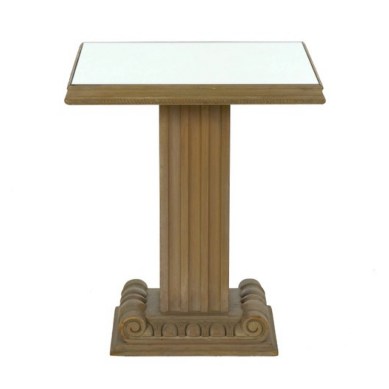

In [ ]:


img_path = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/human/09751b3d-fb3a-4ccd-b835-1f2210d70fa9.jpg"
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()